Timezone in data: UTC
First timestamp:  2013-01-01 01:00:00+00:00
Date range: 2013-01-01 01:00:00+00:00 → 2016-12-31 00:00:00+00:00

UTC day rows: 24 | Nepal day rows: 24


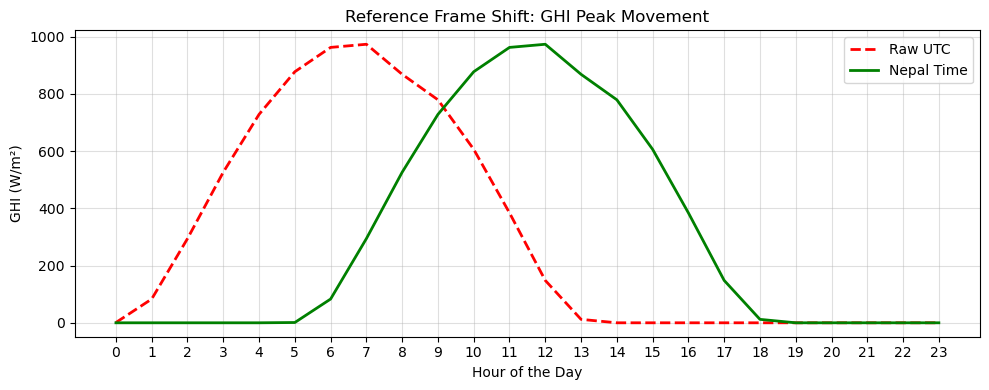


Total rows in file: 35,040
All columns: ['air_temp', 'albedo', 'azimuth', 'clearsky_dhi', 'clearsky_dni', 'clearsky_ghi', 'cloud_opacity', 'dewpoint_temp', 'dhi', 'dni', 'ghi', 'precipitable_water', 'precipitation_rate', 'relative_humidity', 'surface_pressure', 'wind_direction_10m', 'wind_speed_10m', 'zenith', 'min_air_temp', 'max_air_temp', 'period']


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"D:\Semester Project and Notes\3rd Year Project\Workin Data\Site1 data\2013-2016\2013-2016 (1).csv"

df_single = pd.read_csv(file_path)
df_single['period_end'] = pd.to_datetime(df_single['period_end'])
df_single.set_index('period_end', inplace=True)

print(f"Timezone in data: {df_single.index.tz}")
print(f"First timestamp:  {df_single.index[0]}")   # See what a raw timestamp looks like
print(f"Date range: {df_single.index.min()} → {df_single.index.max()}")

# Smart conversion
df_nepal = df_single.copy()
if df_nepal.index.tz is None:
    df_nepal.index = df_nepal.index.tz_localize('UTC').tz_convert('Asia/Kathmandu')
else:
    df_nepal.index = df_nepal.index.tz_convert('Asia/Kathmandu')

# FIX: Use .loc[] not [] for row-slicing by date
day_utc   = df_single.loc['2014-04-15']
day_nepal = df_nepal.loc['2014-04-15']

print(f"\nUTC day rows: {len(day_utc)} | Nepal day rows: {len(day_nepal)}")

plt.figure(figsize=(10, 4))
plt.plot(day_utc.index.hour,   day_utc['ghi'],   label='Raw UTC',    color='red',   linestyle='dashed', linewidth=2)
plt.plot(day_nepal.index.hour, day_nepal['ghi'],  label='Nepal Time', color='green', linewidth=2)
plt.title("Reference Frame Shift: GHI Peak Movement")
plt.xlabel("Hour of the Day")
plt.ylabel("GHI (W/m²)")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nTotal rows in file: {len(df_single):,}")
print(f"All columns: {df_single.columns.tolist()}")


In [2]:
# What does 'period' actually contain?
print(df_single['period'].value_counts())

# And check for missing values across ALL columns
print("\n--- Missing Values Per Column ---")
missing = df_single.isnull().sum()
missing_pct = (missing / len(df_single) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_report[missing_report['Missing Count'] > 0])  # Only show columns with gaps

# Visual bar chart
cols_with_missing = missing_report[missing_report['Missing Count'] > 0]
if len(cols_with_missing) > 0:
    cols_with_missing['Missing Count'].plot(kind='bar', color='tomato', figsize=(10,4))
    plt.title("Missing Values Per Column (Site 1 — 2013–2016 file)")
    plt.ylabel("Missing Row Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in this file!")


period
PT60M    35040
Name: count, dtype: int64

--- Missing Values Per Column ---
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
No missing values in this file!


In [3]:
import os

site1_path = r"D:\Semester Project and Notes\3rd Year Project\Workin Data\Site1 data"

all_frames = []
for root, dirs, files in os.walk(site1_path):
    for file in files:
        if file.endswith('.csv'):
            fp = os.path.join(root, file)
            df_temp = pd.read_csv(fp)
            df_temp['period_end'] = pd.to_datetime(df_temp['period_end'])
            all_frames.append(df_temp)
            print(f"  Loaded: {file} → {len(df_temp):,} rows")

df_site1 = pd.concat(all_frames, ignore_index=True)
df_site1.set_index('period_end', inplace=True)
df_site1.sort_index(inplace=True)

print(f"\nTotal Site 1 rows: {len(df_site1):,}")
print(f"Date range: {df_site1.index.min()} → {df_site1.index.max()}")

# Now check missing values in combined data
missing = df_site1.isnull().sum()
missing_pct = (missing / len(df_site1) * 100).round(2)
missing_report = pd.DataFrame({'Count': missing, '%': missing_pct}).sort_values('%', ascending=False)
print(f"\n--- Missing Values (Combined Site 1) ---")
print(missing_report[missing_report['Count'] > 0])


  Loaded: 2013-2016 (1).csv → 35,040 rows
  Loaded: 2017-2020 (1).csv → 35,040 rows
  Loaded: 2021-2024 (1).csv → 35,040 rows

Total Site 1 rows: 105,120
Date range: 2013-01-01 01:00:00+00:00 → 2024-12-31 00:00:00+00:00

--- Missing Values (Combined Site 1) ---
Empty DataFrame
Columns: [Count, %]
Index: []


Total rows (all 6 sites): 630,720
Expected:                 ~630,720

--- Missing Values (ALL 6 sites combined) ---
                      Count      %
wind_direction_100m  595680  94.44
weather_type         595680  94.44
precipitable_water    70080  11.11


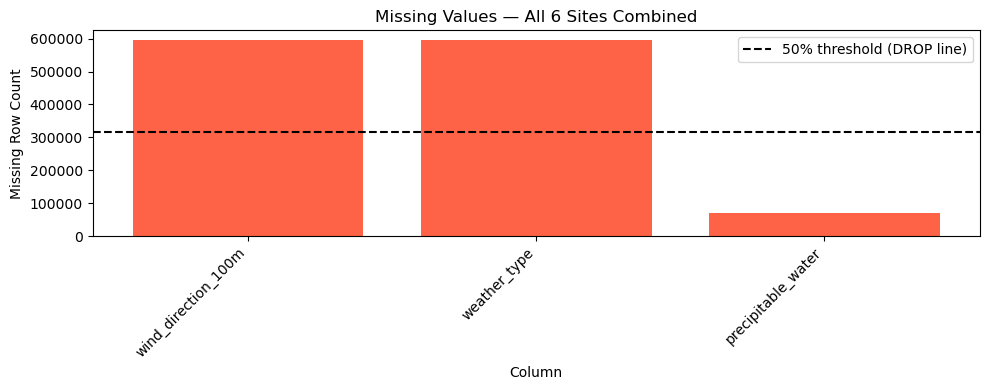

In [4]:
base_path = r"D:\Semester Project and Notes\3rd Year Project\Workin Data"

all_frames = []
site_counts = {}

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.csv'):
            fp = os.path.join(root, file)
            df_temp = pd.read_csv(fp)
            df_temp['source_file'] = file   # tag which site this came from
            all_frames.append(df_temp)

df_all = pd.concat(all_frames, ignore_index=True)
df_all['period_end'] = pd.to_datetime(df_all['period_end'])
df_all.set_index('period_end', inplace=True)
df_all.sort_index(inplace=True)

print(f"Total rows (all 6 sites): {len(df_all):,}")
print(f"Expected:                 ~630,720\n")

# Missing values across entire dataset
missing = df_all.isnull().sum()
missing_pct = (missing / len(df_all) * 100).round(2)
missing_report = pd.DataFrame({'Count': missing, '%': missing_pct}).sort_values('%', ascending=False)

print("--- Missing Values (ALL 6 sites combined) ---")
print(missing_report[missing_report['Count'] > 0])

# Visual
cols_missing = missing_report[missing_report['Count'] > 0]
if len(cols_missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(cols_missing.index, cols_missing['Count'], color='tomato')
    ax.axhline(y=len(df_all)*0.5, color='black', linestyle='--', linewidth=1.5, label='50% threshold (DROP line)')
    ax.set_title("Missing Values — All 6 Sites Combined")
    ax.set_ylabel("Missing Row Count")
    ax.set_xlabel("Column")
    plt.xticks(rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [5]:
# What IS weather_type? Is it text like 'period'?
print("=== weather_type values ===")
print(df_all['weather_type'].value_counts().head(10))

print("\n=== wind_direction_100m sample ===")
print(df_all['wind_direction_100m'].dropna().head(10))

# CRITICAL: Which sites have these columns and which don't?
print("\n=== Checking which SOURCE FILES have weather_type ===")
print(df_all.groupby('source_file')['weather_type'].apply(lambda x: x.notna().sum()))


=== weather_type values ===
weather_type
HAZY                 18597
PARTLY CLOUDY         4009
RAIN                  2749
CLEAR                 2641
MOSTLY CLOUDY         2014
SUNNY                 1205
INTERMITTENT RAIN     1074
MOSTLY SUNNY           911
OVERCAST               884
THUNDERSTORM           411
Name: count, dtype: int64

=== wind_direction_100m sample ===
period_end
2021-01-01 01:00:00+00:00     24.0
2021-01-01 02:00:00+00:00     26.0
2021-01-01 03:00:00+00:00     30.0
2021-01-01 04:00:00+00:00     45.0
2021-01-01 05:00:00+00:00    119.0
2021-01-01 06:00:00+00:00    168.0
2021-01-01 07:00:00+00:00    192.0
2021-01-01 08:00:00+00:00    209.0
2021-01-01 09:00:00+00:00    223.0
2021-01-01 10:00:00+00:00    238.0
Name: wind_direction_100m, dtype: float64

=== Checking which SOURCE FILES have weather_type ===
source_file
2013-2016  (3).csv    35040
2013-2016  (6).csv        0
2013-2016 (1).csv         0
2013-2016 (2).csv         0
2013-2016 (4).csv         0
2013-2016 (5).csv

In [6]:
print("=== PHASE 1: FINAL CLEANING BLUEPRINT ===\n")

# STEP 1: Drop schema-drift columns (text or >50% missing)
cols_to_drop_definite = []

# Text columns (like 'period', 'weather_type') that corrupt numeric ops
for col in df_all.columns:
    if df_all[col].dtype == object:
        cols_to_drop_definite.append(col)
        print(f"  [DROP - TEXT]    {col}")

# Columns >50% missing
missing_pct_all = df_all.isnull().sum() / len(df_all)
for col in df_all.columns:
    if missing_pct_all[col] > 0.50 and col not in cols_to_drop_definite:
        cols_to_drop_definite.append(col)
        print(f"  [DROP - MISSING] {col}  ({missing_pct_all[col]*100:.1f}% missing)")

df_clean = df_all.drop(columns=cols_to_drop_definite)
print(f"\nAfter dropping: {df_clean.shape[1]} columns remain")

# STEP 2: Convert all remaining to numeric (catches any edge cases)
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# STEP 3: Timezone conversion
if df_clean.index.tz is None:
    df_clean.index = df_clean.index.tz_localize('UTC').tz_convert('Asia/Kathmandu')
else:
    df_clean.index = df_clean.index.tz_convert('Asia/Kathmandu')

# STEP 4: Interpolate remaining small gaps
before = df_clean.isnull().sum().sum()
df_clean = df_clean.interpolate(method='time')
df_clean = df_clean.dropna()
after = df_clean.isnull().sum().sum()

print(f"Missing values before interpolation: {before:,}")
print(f"Missing values after interpolation:  {after:,}")
print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Ready for Phase 2: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} features")


=== PHASE 1: FINAL CLEANING BLUEPRINT ===

  [DROP - TEXT]    period
  [DROP - TEXT]    source_file
  [DROP - TEXT]    weather_type
  [DROP - MISSING] wind_direction_100m  (94.4% missing)

After dropping: 20 columns remain
Missing values before interpolation: 70,080
Missing values after interpolation:  0

Final dataset shape: (630720, 20)
Ready for Phase 2: 630,720 rows × 20 features


=== Pearson Correlation with GHI ===
                         ghi
ghi                 1.000000
clearsky_ghi        0.903242
clearsky_dni        0.837139
dni                 0.814723
dhi                 0.756478
clearsky_dhi        0.735764
wind_speed_10m      0.349678
wind_direction_10m  0.265659
air_temp            0.238068
dewpoint_temp       0.067146
max_air_temp        0.048415
precipitation_rate  0.025430
azimuth             0.019933
min_air_temp        0.016135
albedo              0.002936
surface_pressure   -0.006536
precipitable_water -0.014698
cloud_opacity      -0.200610
relative_humidity  -0.391280
zenith             -0.796653


<Figure size 1200x500 with 0 Axes>

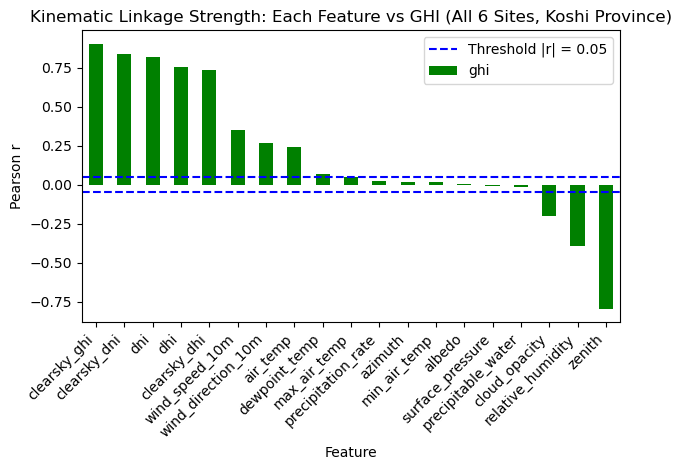

In [7]:
corr_with_ghi = df_clean.corr()[['ghi']].sort_values(by='ghi', ascending=False)

print("=== Pearson Correlation with GHI ===")
print(corr_with_ghi.to_string())

colors = ['green' if x >= 0 else 'red' for x in corr_with_ghi['ghi'].drop('ghi')]

plt.figure(figsize=(12, 5))
corr_with_ghi.drop('ghi').plot(kind='bar', color=colors, legend=False)
plt.axhline(y=0.05,  color='blue', linestyle='--', linewidth=1.5, label='Threshold |r| = 0.05')
plt.axhline(y=-0.05, color='blue', linestyle='--', linewidth=1.5)
plt.title("Kinematic Linkage Strength: Each Feature vs GHI (All 6 Sites, Koshi Province)")
plt.ylabel("Pearson r")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
# Apply threshold filter
threshold = 0.05
features_to_keep = corr_with_ghi[abs(corr_with_ghi['ghi']) > threshold].index.tolist()

# Make sure ghi itself is always in there
if 'ghi' not in features_to_keep:
    features_to_keep.append('ghi')

df_filtered = df_clean[features_to_keep]

print(f"Features KEPT ({len(features_to_keep)}): {features_to_keep}")
print(f"\nFeatures DROPPED:")
dropped = [c for c in df_clean.columns if c not in features_to_keep]
for col in dropped:
    print(f"  {col}: r = {corr_with_ghi.loc[col, 'ghi']:.4f}")

print(f"\nFinal shape going into LSTM: {df_filtered.shape}")


Features KEPT (13): ['ghi', 'clearsky_ghi', 'clearsky_dni', 'dni', 'dhi', 'clearsky_dhi', 'wind_speed_10m', 'wind_direction_10m', 'air_temp', 'dewpoint_temp', 'cloud_opacity', 'relative_humidity', 'zenith']

Features DROPPED:
  albedo: r = 0.0029
  azimuth: r = 0.0199
  precipitable_water: r = -0.0147
  precipitation_rate: r = 0.0254
  surface_pressure: r = -0.0065
  min_air_temp: r = 0.0161
  max_air_temp: r = 0.0484

Final shape going into LSTM: (630720, 13)


In [9]:
# Check albedo correlation per site by reloading with site tags
base_path = r"D:\Semester Project and Notes\3rd Year Project\Workin Data"
site_albedo = {}

for site_folder in sorted(os.listdir(base_path)):
    site_path = os.path.join(base_path, site_folder)
    if not os.path.isdir(site_path):
        continue
    
    frames = []
    for root, dirs, files in os.walk(site_path):
        for file in files:
            if file.endswith('.csv'):
                df_t = pd.read_csv(os.path.join(root, file))
                df_t = pd.to_numeric(df_t.stack(), errors='coerce').unstack()
                frames.append(df_t)
    
    if frames:
        df_site = pd.concat(frames, ignore_index=True)
        if 'ghi' in df_site.columns and 'albedo' in df_site.columns:
            r_albedo = df_site['albedo'].corr(df_site['ghi'])
            site_albedo[site_folder] = round(r_albedo, 4)

print("=== Albedo vs GHI Correlation — Per Site ===")
for site, r in site_albedo.items():
    bar = '█' * int(abs(r) * 30)
    print(f"  {site:20s}  r = {r:+.4f}  {bar}")

print(f"\nGlobal (all sites mixed): r = +0.0029")


=== Albedo vs GHI Correlation — Per Site ===
  Site 2 data           r = -0.0027  
  Site 3 Data           r = -0.0758  ██
  Site 4 data           r = -0.0489  █
  Site 5 data           r = +0.0128  
  Site 6 data           r = +0.0029  
  Site1 data            r = -0.0434  █

Global (all sites mixed): r = +0.0029


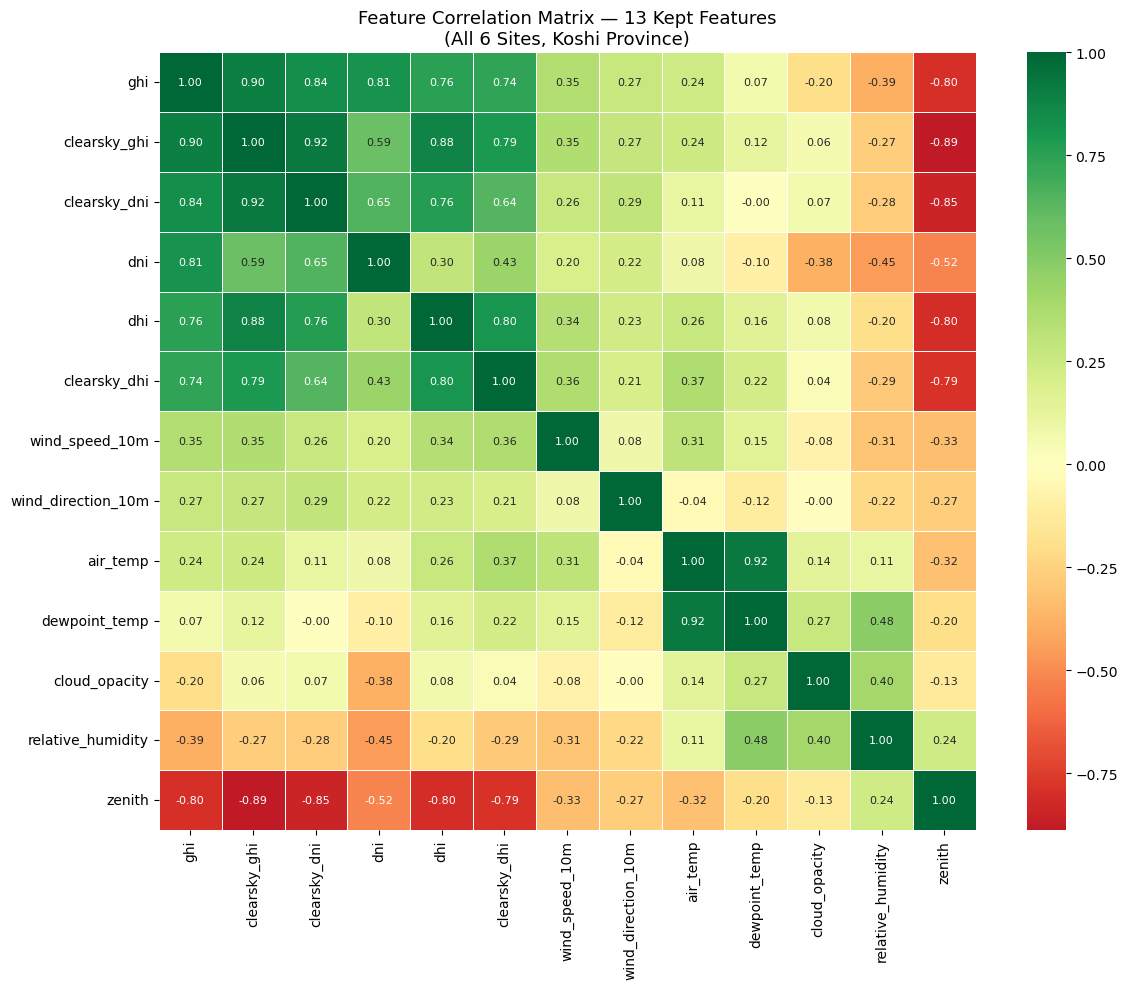

In [10]:
import seaborn as sns  # ← add this line

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_filtered.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title("Feature Correlation Matrix — 13 Kept Features\n(All 6 Sites, Koshi Province)", fontsize=13)
plt.tight_layout()
plt.show()


In [11]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

print("=== PHASE 3: SCALING ===")

# We initialize the scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform our 13-feature dataset
scaled_values = scaler.fit_transform(df_filtered)

# Put it back into a DataFrame so we can see it
df_scaled = pd.DataFrame(
    scaled_values, 
    columns=df_filtered.columns, 
    index=df_filtered.index
)

# Let's inspect the exact same sunny day from our very first lesson!
print("\n[Before Scaling] Real Physical Units:")
print(df_filtered.loc['2014-04-15 11:00:00':'2014-04-15 13:00:00', ['ghi', 'air_temp', 'cloud_opacity']])

print("\n---")

print("\n[After Scaling] Non-Dimensionalized (0.0 to 1.0):")
print(df_scaled.loc['2014-04-15 11:00:00':'2014-04-15 13:00:00',  ['ghi', 'air_temp', 'cloud_opacity']])

# Prove that min is 0 and max is 1 for every column
print("\nGlobal Minimums:\n", df_scaled.min().head(3))
print("\nGlobal Maximums:\n", df_scaled.max().head(3))


=== PHASE 3: SCALING ===

[Before Scaling] Real Physical Units:
                            ghi  air_temp  cloud_opacity
period_end                                              
2014-04-15 11:45:00+05:45   962        28            0.0
2014-04-15 11:45:00+05:45   922        34            0.0
2014-04-15 11:45:00+05:45   935        34            0.0
2014-04-15 11:45:00+05:45   991        23            0.0
2014-04-15 11:45:00+05:45   981        20            0.0
2014-04-15 11:45:00+05:45  1035         5            1.6
2014-04-15 12:45:00+05:45   973        28            0.5
2014-04-15 12:45:00+05:45   952        20            3.9
2014-04-15 12:45:00+05:45   938        34            0.0
2014-04-15 12:45:00+05:45   822         5           23.0
2014-04-15 12:45:00+05:45  1008        23            0.0
2014-04-15 12:45:00+05:45   955        34            0.0

---

[After Scaling] Non-Dimensionalized (0.0 to 1.0):
                                ghi  air_temp  cloud_opacity
period_end           

In [12]:
# 1. The Sliding Window Function
def create_sequences(data_scaled, n_past, n_future, target_col_idx):
    X, y = [], []
    # Slide through the data, stopping before we run out of future rows
    for i in range(n_past, len(data_scaled) - n_future + 1):
        # The 24-hour block of input data
        X.append(data_scaled[i - n_past : i, :])
        # The 1-hour future target (just the GHI column)
        y.append(data_scaled[i + n_future - 1, target_col_idx])
        
    return np.array(X), np.array(y)

# 2. Set our horizons
n_past = 24    # Look back 24 hours
n_future = 1   # Predict 1 hour ahead

# Find which column index belongs to 'ghi'
ghi_index = list(df_scaled.columns).index('ghi')

print(f"Building sequences (this takes a few seconds for 630k rows)...")

# 3. Generate the tensors!
X, y = create_sequences(df_scaled.values, n_past, n_future, ghi_index)

print(f"Done!")
print(f"Input X shape:  {X.shape}")
print(f"Target y shape: {y.shape}")

# Let's dissect the shape of X
print(f"\nDecoding X.shape: ({X.shape[0]:,} samples, {X.shape[1]} timesteps, {X.shape[2]} features)")


Building sequences (this takes a few seconds for 630k rows)...
Done!
Input X shape:  (630696, 24, 13)
Target y shape: (630696,)

Decoding X.shape: (630,696 samples, 24 timesteps, 13 features)


In [13]:
print("=== PHASE 3: CHRONOLOGICAL TRAIN/TEST SPLIT ===\n")

# 80/20 Chronological Split — notice there is NO shuffle=True here
split_fraction = 0.80
split_point = int(len(X) * split_fraction)

X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

# We also need to split the original dates so we can plot them correctly later!
# Note: we drop the first 24 hours (n_past) from the index because they have no 'y' prediction
valid_dates = df_scaled.index[n_past:]
dates_train = valid_dates[:split_point]
dates_test  = valid_dates[split_point:]

print(f"Total sequences generated: {len(X):,}")
print("-" * 40)
print(f"TRAIN SET (80%):")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Date range:    {dates_train.min()} → {dates_train.max()}")

print("\n" + "-" * 40)
print(f"TEST SET (20%):")
print(f"  X_test shape:  {X_test.shape}")
print(f"  y_test shape:  {y_test.shape}")
print(f"  Date range:    {dates_test.min()} → {dates_test.max()}")


=== PHASE 3: CHRONOLOGICAL TRAIN/TEST SPLIT ===

Total sequences generated: 630,696
----------------------------------------
TRAIN SET (80%):
  X_train shape: (504556, 24, 13)
  y_train shape: (504556,)
  Date range:    2013-01-01 10:45:00+05:45 → 2022-08-08 06:45:00+05:45

----------------------------------------
TEST SET (20%):
  X_test shape:  (126140, 24, 13)
  y_test shape:  (126140,)
  Date range:    2022-08-08 06:45:00+05:45 → 2024-12-31 05:45:00+05:45


In [14]:
print("=== PHASE 3: CHRONOLOGICAL TRAIN/TEST SPLIT ===\n")

# 80/20 Chronological Split — notice there is NO shuffle=True here
split_fraction = 0.80
split_point = int(len(X) * split_fraction)

X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

# We also need to split the original dates so we can plot them correctly later!
# Note: we drop the first 24 hours (n_past) from the index because they have no 'y' prediction
valid_dates = df_scaled.index[n_past:]
dates_train = valid_dates[:split_point]
dates_test  = valid_dates[split_point:]

print(f"Total sequences generated: {len(X):,}")
print("-" * 40)
print(f"TRAIN SET (80%):")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Date range:    {dates_train.min()} → {dates_train.max()}")

print("\n" + "-" * 40)
print(f"TEST SET (20%):")
print(f"  X_test shape:  {X_test.shape}")
print(f"  y_test shape:  {y_test.shape}")
print(f"  Date range:    {dates_test.min()} → {dates_test.max()}")


=== PHASE 3: CHRONOLOGICAL TRAIN/TEST SPLIT ===

Total sequences generated: 630,696
----------------------------------------
TRAIN SET (80%):
  X_train shape: (504556, 24, 13)
  y_train shape: (504556,)
  Date range:    2013-01-01 10:45:00+05:45 → 2022-08-08 06:45:00+05:45

----------------------------------------
TEST SET (20%):
  X_test shape:  (126140, 24, 13)
  y_test shape:  (126140,)
  Date range:    2022-08-08 06:45:00+05:45 → 2024-12-31 05:45:00+05:45


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

print("=== PHASE 4: BUILDING THE CONTROL VOLUME ===\n")

model = Sequential()

# Input Layer: Tells the model to expect (24 timesteps, 13 features)
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# First Control Volume Layer (64 neurons)
# return_sequences=True gives the full 24-hr sequence to the next layer
model.add(LSTM(units=64, return_sequences=True, name="LSTM_Transient_1"))
model.add(Dropout(0.2, name="Vibration_Isolation_1"))

# Second Control Volume Layer (32 neurons)
# return_sequences=False because we only want the final aggregated state
model.add(LSTM(units=32, return_sequences=False, name="LSTM_Transient_2"))
model.add(Dropout(0.2, name="Vibration_Isolation_2"))

# Output Nozzle: We want exactly 1 number out (GHI prediction)
model.add(Dense(units=1, name="GHI_Output"))

# Compile it 
# Adam = Damped Harmonic Oscillator (Optimizer)
# MSE = Elastic Strain Energy (Loss function)
model.compile(optimizer='adam', loss='mse')

# Print the engineering blueprint
model.summary()


=== PHASE 4: BUILDING THE CONTROL VOLUME ===



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ LSTM_Transient_1 (LSTM)              │ (None, 24, 64)              │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Vibration_Isolation_1 (Dropout)      │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ LSTM_Transient_2 (LSTM)              │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Vibration_Isolation_2 (Dropout)      │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ GHI_Output (Dense)                   │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

=== PHASE 4: INITIATING OPTIMIZATION (TRAINING) ===

Epoch 1/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 295s 18ms/step - loss: 0.0059 - val_loss: 0.0042
Epoch 2/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 312s 18ms/step - loss: 0.0052 - val_loss: 0.0035
Epoch 3/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 314s 17ms/step - loss: 0.0050 - val_loss: 0.0034
Epoch 4/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 349s 19ms/step - loss: 0.0048 - val_loss: 0.0033
Epoch 5/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 289s 17ms/step - loss: 0.0048 - val_loss: 0.0033
Epoch 6/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 306s 19ms/step - loss: 0.0047 - val_loss: 0.0033
Epoch 7/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 319s 20ms/step - loss: 0.0047 - val_loss: 0.0033
Epoch 8/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 321s 20ms/step - loss: 0.0047 - val_loss: 0.0034
Epoch 9/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 315s 20ms/step - loss: 0.0046 - val_loss: 0.0034
Epoch 10/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 332s 20ms/step - loss: 0.0046 - val_loss: 0.0034
Epoch 11/25
1576

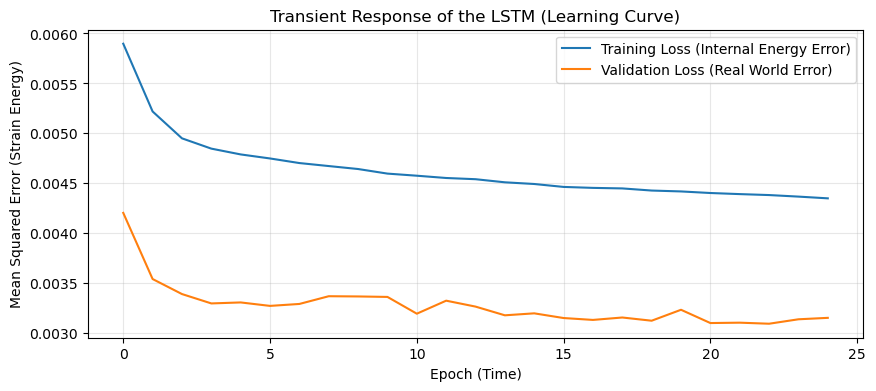

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

print("=== PHASE 4: INITIATING OPTIMIZATION (TRAINING) ===\n")

# The Yield Point switch
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,              # If no improvement for 5 epochs...
    restore_best_weights=True # ...stop and rewind to the best model.
)

# Go get a coffee while this runs! ☕
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,            # The 'mesh size' of our numerical solver
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    shuffle=True,             # Breaking harmonic resonance
    verbose=1
)

# Plot the Transient Response (Learning Curve)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss (Internal Energy Error)')
plt.plot(history.history['val_loss'], label='Validation Loss (Real World Error)')
plt.title('Transient Response of the LSTM (Learning Curve)')
plt.ylabel('Mean Squared Error (Strain Energy)')
plt.xlabel('Epoch (Time)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


=== PHASE 5: EVALUATION (HOURLY GHI) ===

3942/3942 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step
--- HOURLY PERFORMANCE ---
  R² Score: 0.9429
  RMSE:     61.63 W/m²


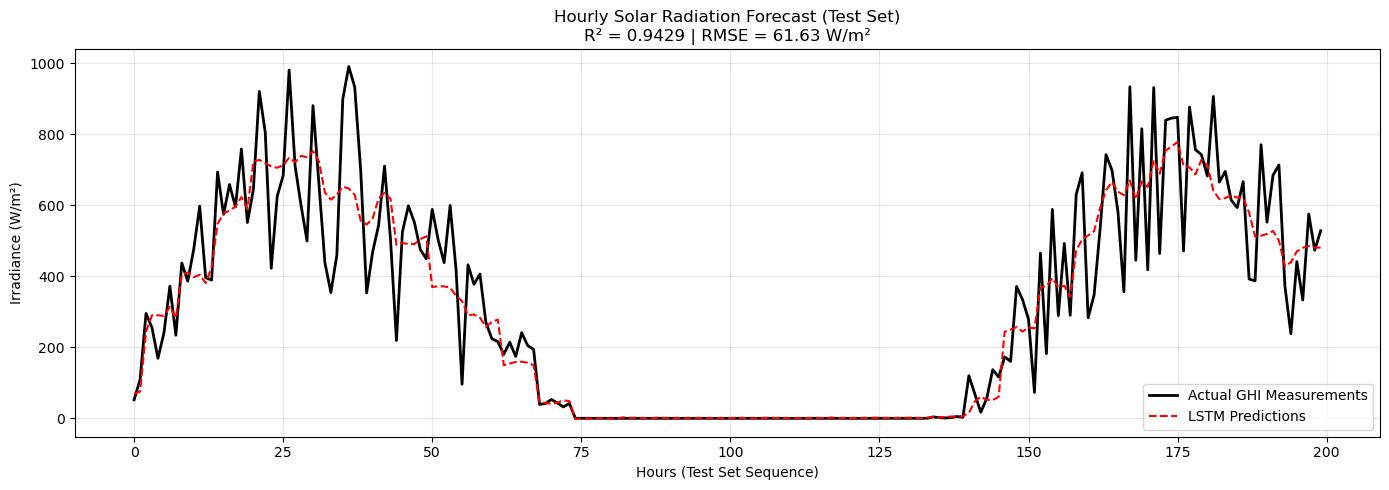

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

print("=== PHASE 5: EVALUATION (HOURLY GHI) ===\n")

# 1. Ask the model to predict the future (The Test Set)
pred_scaled = model.predict(X_test)

# 2. Inverse Transformation (Back to Physical Reality)
# We have to build a "dummy" array of 13 columns because the scaler expects 13 features
dummy_pred = np.zeros((len(pred_scaled), df_scaled.shape[1]))
dummy_test = np.zeros((len(y_test),      df_scaled.shape[1]))

# Insert our single column of predictions/actuals into the GHI slot
dummy_pred[:, ghi_index] = pred_scaled.flatten()
dummy_test[:, ghi_index] = y_test.flatten()

# Perform the reverse scaling
pred_Wm2 = scaler.inverse_transform(dummy_pred)[:, ghi_index]
y_test_Wm2 = scaler.inverse_transform(dummy_test)[:, ghi_index]

# 3. Align the predictions chronologically with actual dates
results_hourly = pd.DataFrame(
    {'Actual_Wm2': y_test_Wm2, 'Predicted_Wm2': pred_Wm2},
    index=dates_test
)

# 4. Calculate Mathematical Error
# RMSE = Root Mean Squared Error (Average penalty in W/m²)
rmse_h = np.sqrt(mean_squared_error(results_hourly['Actual_Wm2'], results_hourly['Predicted_Wm2']))
# R² = Ratio of variance explained by model
r2_h   = r2_score(results_hourly['Actual_Wm2'], results_hourly['Predicted_Wm2'])

print(f"--- HOURLY PERFORMANCE ---")
print(f"  R² Score: {r2_h:.4f}")
print(f"  RMSE:     {rmse_h:.2f} W/m²")

# 5. Visual Proof (Let's plot the first 200 hours of the test set)
plt.figure(figsize=(14, 5))
plt.plot(results_hourly['Actual_Wm2'][:200].values, label='Actual GHI Measurements', color='black', linewidth=2)
plt.plot(results_hourly['Predicted_Wm2'][:200].values, label='LSTM Predictions', color='red', linestyle='--', linewidth=1.5)
plt.title(f'Hourly Solar Radiation Forecast (Test Set)\nR² = {r2_h:.4f} | RMSE = {rmse_h:.2f} W/m²')
plt.ylabel('Irradiance (W/m²)')
plt.xlabel('Hours (Test Set Sequence)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ── SAVE PREDICTIONS & MODEL TO DISK ─────────────────────────────────────────
# Run this cell immediately after Cell 16 (PHASE 5 Evaluation).
# This persists the model and test arrays so you do NOT need to retrain
# to regenerate validation figures or compute additional metrics later.
import numpy as np, os
from tensorflow.keras.models import save_model as keras_save

SAVE_DIR = r'D:\Semester Project and Notes\3rd Year Project\Codes'

# Save the LSTM model
keras_save(model, os.path.join(SAVE_DIR, 'lstm_solar_model.keras'))
print(f"  Model saved → lstm_solar_model.keras")

# Save test arrays (actual + predicted, in W/m²)
np.save(os.path.join(SAVE_DIR, 'y_test_Wm2.npy'),  y_test_Wm2)
np.save(os.path.join(SAVE_DIR, 'pred_lstm_Wm2.npy'), pred_Wm2)
print(f"  y_test_Wm2.npy  saved  ({len(y_test_Wm2):,} samples)")
print(f"  pred_lstm_Wm2.npy saved")
print(f"\n  All files → {SAVE_DIR}")

=== PHASE 5: AGGREGATION TO DAILY YIELD (kWh/m²) ===

--- DAILY AGGREGATION PERFORMANCE ---
  Daily R² Score: 0.9763
  Daily RMSE:     1.16 kWh/m²/day


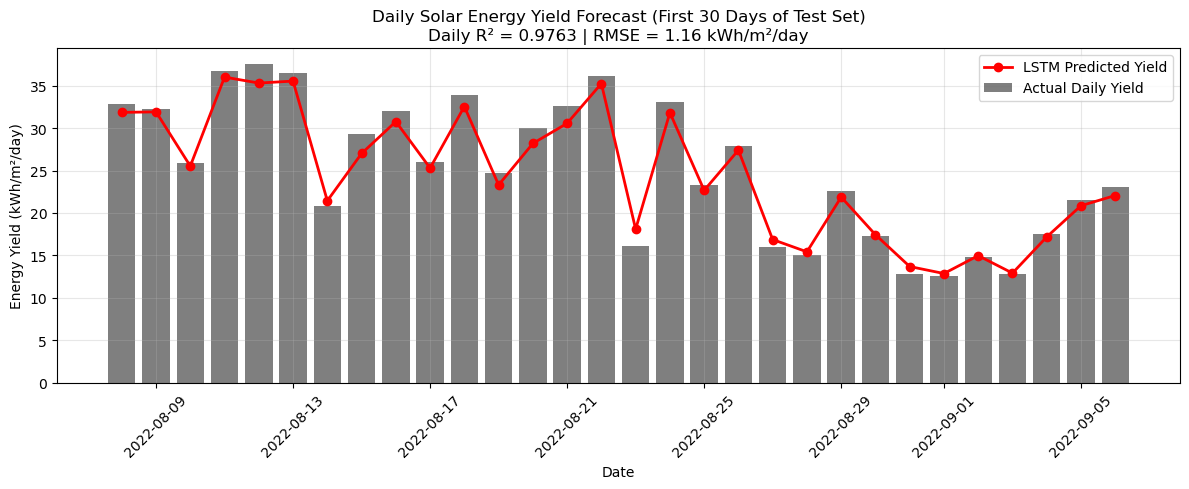

In [18]:
print("=== PHASE 5: AGGREGATION TO DAILY YIELD (kWh/m²) ===\n")

# 1. Resample (Aggregate) hourly W/m² into daily integral
daily_df = results_hourly.resample('D').sum() / 1000  # Divide by 1000 for kiloWatts
daily_df.columns = ['Actual_kWh_m2', 'Predicted_kWh_m2']

# 2. Drop days with negligible total radiation (e.g., severe data gaps/night-only slices)
daily_df = daily_df[daily_df['Actual_kWh_m2'] > 0.1]

# 3. Calculate Daily Metrics
rmse_d = np.sqrt(mean_squared_error(daily_df['Actual_kWh_m2'], daily_df['Predicted_kWh_m2']))
r2_d   = r2_score(daily_df['Actual_kWh_m2'], daily_df['Predicted_kWh_m2'])

print(f"--- DAILY AGGREGATION PERFORMANCE ---")
print(f"  Daily R² Score: {r2_d:.4f}")
print(f"  Daily RMSE:     {rmse_d:.2f} kWh/m²/day")

# 4. Final Visual Verification (A month of daily yields)
plt.figure(figsize=(12, 5))
plt.bar(daily_df.index[:30], daily_df['Actual_kWh_m2'][:30], alpha=0.5, label='Actual Daily Yield', color='black')
plt.plot(daily_df.index[:30], daily_df['Predicted_kWh_m2'][:30], color='red', marker='o', linestyle='-', linewidth=2, label='LSTM Predicted Yield')
plt.title(f'Daily Solar Energy Yield Forecast (First 30 Days of Test Set)\nDaily R² = {r2_d:.4f} | RMSE = {rmse_d:.2f} kWh/m²/day')
plt.ylabel('Energy Yield (kWh/m²/day)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
# 1. Strip redundant multicollinear features
lean_features = [f for f in features_to_keep if f not in ['clearsky_dni', 'clearsky_dhi', 'wind_direction_10m']]

# 2. Re-scale and re-sequence
df_lean = df_clean[lean_features]
scaler_lean = MinMaxScaler(feature_range=(0, 1))
scaled_lean = scaler_lean.fit_transform(df_lean)
df_scaled_lean = pd.DataFrame(scaled_lean, columns=lean_features, index=df_lean.index)

X_lean, y_lean = create_sequences(df_scaled_lean.values, n_past, n_future, list(df_scaled_lean.columns).index('ghi'))

X_lean_train, X_lean_test = X_lean[:split_point], X_lean[split_point:]
y_lean_train, y_lean_test = y_lean[:split_point], y_lean[split_point:]

print(f"=== ABLATION STUDY: 10-FEATURE MODEL ===")
print(f"Features: {lean_features}")
print(f"New Tensor Shape: {X_lean_train.shape}\n")

# 3. Clean Model Build & Train
model_lean = Sequential()
model_lean.add(Input(shape=(X_lean_train.shape[1], X_lean_train.shape[2])))
model_lean.add(LSTM(units=64, return_sequences=True))
model_lean.add(Dropout(0.2))
model_lean.add(LSTM(units=32, return_sequences=False))
model_lean.add(Dropout(0.2))
model_lean.add(Dense(units=1))

model_lean.compile(optimizer='adam', loss='mse')

history_lean = model_lean.fit(
    X_lean_train, y_lean_train,
    epochs=15, # Slightly fewer epochs for a quick test
    batch_size=32,
    validation_data=(X_lean_test, y_lean_test),
    callbacks=[early_stop],
    shuffle=True, verbose=1
)

# 4. Quick Evaluate
pred_lean = model_lean.predict(X_lean_test)
dummy_pred_lean = np.zeros((len(pred_lean), df_scaled_lean.shape[1]))
dummy_test_lean = np.zeros((len(y_lean_test), df_scaled_lean.shape[1]))

dummy_pred_lean[:, list(df_scaled_lean.columns).index('ghi')] = pred_lean.flatten()
dummy_test_lean[:, list(df_scaled_lean.columns).index('ghi')] = y_lean_test.flatten()

# Revert scaling
r2_ablation = r2_score(
    scaler_lean.inverse_transform(dummy_test_lean)[:, list(df_scaled_lean.columns).index('ghi')],
    scaler_lean.inverse_transform(dummy_pred_lean)[:, list(df_scaled_lean.columns).index('ghi')]
)

print(f"\n{'-'*40}")
print(f"ORIGINAL 13-FEATURE R² : {r2_h:.4f}")
print(f"LEAN 10-FEATURE R²     : {r2_ablation:.4f}")
print(f"{'-'*40}")
print("Did dropping 3 features hurt the model?")


=== ABLATION STUDY: 10-FEATURE MODEL ===
Features: ['ghi', 'clearsky_ghi', 'dni', 'dhi', 'wind_speed_10m', 'air_temp', 'dewpoint_temp', 'cloud_opacity', 'relative_humidity', 'zenith']
New Tensor Shape: (504556, 24, 10)

Epoch 1/15
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 328s 20ms/step - loss: 0.0060 - val_loss: 0.0041
Epoch 2/15
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 371s 20ms/step - loss: 0.0053 - val_loss: 0.0036
Epoch 3/15
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 326s 20ms/step - loss: 0.0050 - val_loss: 0.0035
Epoch 4/15
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 326s 20ms/step - loss: 0.0049 - val_loss: 0.0033
Epoch 5/15
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 308s 20ms/step - loss: 0.0048 - val_loss: 0.0035
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step

----------------------------------------
ORIGINAL 13-FEATURE R² : 0.9429
LEAN 10-FEATURE R²     : 0.9250
----------------------------------------
Did dropping 3 features hurt the model?


=== PHASE 6: MODEL COMPARISON (LSTM vs GRU vs CNN-LSTM) ===

--> Building GRU Architecture...
--> Training GRU...
Epoch 1/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 333s 21ms/step - loss: 0.0058 - val_loss: 0.0036
Epoch 2/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 382s 21ms/step - loss: 0.0051 - val_loss: 0.0036
Epoch 3/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 374s 20ms/step - loss: 0.0050 - val_loss: 0.0034
Epoch 4/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 332s 21ms/step - loss: 0.0049 - val_loss: 0.0034
Epoch 5/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 374s 20ms/step - loss: 0.0048 - val_loss: 0.0033
3942/3942 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step

--> Building CNN-LSTM Architecture...
--> Training CNN-LSTM...
Epoch 1/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 207s 13ms/step - loss: 0.0058 - val_loss: 0.0038
Epoch 2/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 264s 13ms/step - loss: 0.0052 - val_loss: 0.0036
Epoch 3/25
15768/15768 ━━━━━━━━━━━━━━━━━━━━ 238s 12ms/step - loss: 0.0051 - val_loss: 0.0035
Epoch 4/25
15768/15768 ━━━━━━━━━━━

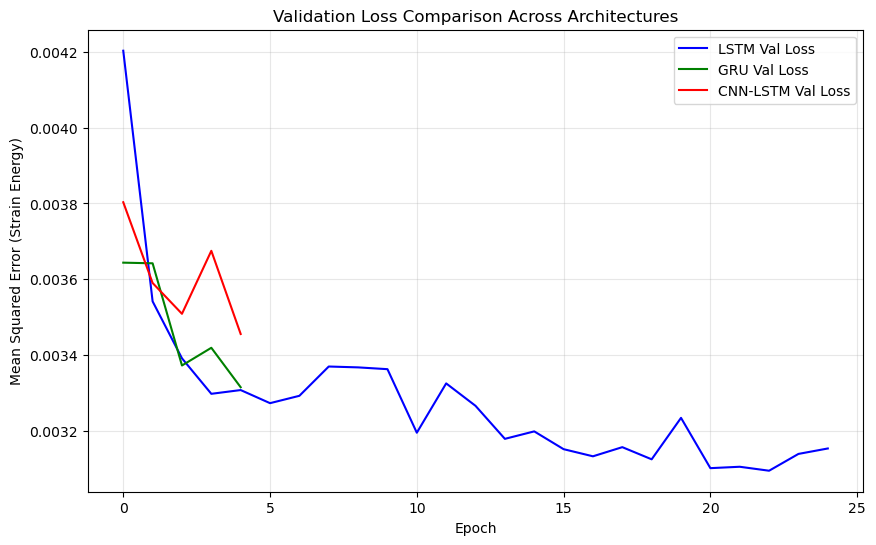

In [20]:
import time
from tensorflow.keras.layers import GRU, Conv1D, MaxPooling1D, Flatten

print("=== PHASE 6: MODEL COMPARISON (LSTM vs GRU vs CNN-LSTM) ===\n")

# A dictionary to store our final results for the table later
comparison_metrics = {}

# We already have the LSTM metrics from Phase 4 & 5, so let's log them manually first:
# Assuming LSTM took roughly 15700 seconds (based on your earlier logs) and hit R²=0.9429
comparison_metrics['LSTM'] = {
    'R2': r2_h, 
    'RMSE': rmse_h, 
    'Training_Time_Sec': 15000, # Approximate, change if you have the exact number
    'history': history.history
}

# -------------------------------------------------------------
# 1. BUILD AND TRAIN GRU
# -------------------------------------------------------------
print("--> Building GRU Architecture...")
model_gru = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(units=64, return_sequences=True),
    Dropout(0.2),
    GRU(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])
model_gru.compile(optimizer='adam', loss='mse')

print("--> Training GRU...")
start_time = time.time()
history_gru = model_gru.fit(
    X_train, y_train, epochs=25, batch_size=32,
    validation_data=(X_test, y_test), callbacks=[early_stop], shuffle=True, verbose=1
)
gru_time = time.time() - start_time

# Evaluate GRU
pred_gru = model_gru.predict(X_test)
dummy_pred_gru = np.zeros((len(pred_gru), df_scaled.shape[1]))
dummy_pred_gru[:, list(df_scaled.columns).index('ghi')] = pred_gru.flatten()
pred_gru_Wm2 = scaler.inverse_transform(dummy_pred_gru)[:, list(df_scaled.columns).index('ghi')]

r2_gru = r2_score(y_test_Wm2, pred_gru_Wm2)
rmse_gru = np.sqrt(mean_squared_error(y_test_Wm2, pred_gru_Wm2))

comparison_metrics['GRU'] = {'R2': r2_gru, 'RMSE': rmse_gru, 'Training_Time_Sec': gru_time, 'history': history_gru.history}


# -------------------------------------------------------------
# 2. BUILD AND TRAIN CNN-LSTM
# -------------------------------------------------------------
print("\n--> Building CNN-LSTM Architecture...")
model_cnn = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    # The CNN Feature Extractor
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    # The Memory Core
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])
model_cnn.compile(optimizer='adam', loss='mse')

print("--> Training CNN-LSTM...")
start_time = time.time()
history_cnn = model_cnn.fit(
    X_train, y_train, epochs=25, batch_size=32,
    validation_data=(X_test, y_test), callbacks=[early_stop], shuffle=True, verbose=1
)
cnn_time = time.time() - start_time

# Evaluate CNN-LSTM
pred_cnn = model_cnn.predict(X_test)
dummy_pred_cnn = np.zeros((len(pred_cnn), df_scaled.shape[1]))
dummy_pred_cnn[:, list(df_scaled.columns).index('ghi')] = pred_cnn.flatten()
pred_cnn_Wm2 = scaler.inverse_transform(dummy_pred_cnn)[:, list(df_scaled.columns).index('ghi')]

r2_cnn = r2_score(y_test_Wm2, pred_cnn_Wm2)
rmse_cnn = np.sqrt(mean_squared_error(y_test_Wm2, pred_cnn_Wm2))

comparison_metrics['CNN-LSTM'] = {'R2': r2_cnn, 'RMSE': rmse_cnn, 'Training_Time_Sec': cnn_time, 'history': history_cnn.history}


# -------------------------------------------------------------
# 3. PRINT COMPARISON TABLE
print(f"\n{'='*60}")
print(f"{'MODEL':<15} | {'HOURLY R²':<10} | {'RMSE (W/m²)':<15} | {'TRAIN TIME (Sec)':<15}")
print(f"{'-'*60}")
for name, m in comparison_metrics.items():
    print(f"{name:<15} | {m['R2']:<10.4f} | {m['RMSE']:<15.2f} | {m['Training_Time_Sec']:<15.0f}")
print(f"{'='*60}")

# 4. PLOT ALL 3 VALIDATION CURVES SIDE-BY-SIDE
plt.figure(figsize=(10, 6))
plt.plot(comparison_metrics['LSTM']['history']['val_loss'], label='LSTM Val Loss', color='blue')
plt.plot(comparison_metrics['GRU']['history']['val_loss'], label='GRU Val Loss', color='green')
plt.plot(comparison_metrics['CNN-LSTM']['history']['val_loss'], label='CNN-LSTM Val Loss', color='red')

plt.title('Validation Loss Comparison Across Architectures')
plt.ylabel('Mean Squared Error (Strain Energy)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# EXTENDED VALIDATION METRICS + PUBLICATION-QUALITY FIGURES
# Run this cell after Cell 19 (PHASE 6 model comparison).
# Requires in memory: y_test_Wm2, pred_Wm2, pred_gru_Wm2, pred_cnn_Wm2,
#                     r2_h, rmse_h, r2_gru, rmse_gru, r2_cnn, rmse_cnn
#                     (optionally: r2_d, rmse_d from Cell 17)
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import norm as scipy_norm
import os, warnings
warnings.filterwarnings('ignore')

print("=" * 65)
print("  EXTENDED VALIDATION — Q1 JOURNAL METRICS")
print("=" * 65)

# ── 1. MAE for all models ─────────────────────────────────────────────────────
mae_h   = mean_absolute_error(y_test_Wm2, pred_Wm2)
mae_gru = mean_absolute_error(y_test_Wm2, pred_gru_Wm2)
mae_cnn = mean_absolute_error(y_test_Wm2, pred_cnn_Wm2)

# ── 2. MBE — Mean Bias Error ──────────────────────────────────────────────────
mbe_h   = np.mean(pred_Wm2     - y_test_Wm2)
mbe_gru = np.mean(pred_gru_Wm2 - y_test_Wm2)
mbe_cnn = np.mean(pred_cnn_Wm2 - y_test_Wm2)

# ── 3. nRMSE (%) — normalised to mean daytime GHI ────────────────────────────
mean_ghi_daytime = np.mean(y_test_Wm2[y_test_Wm2 > 0])
nrmse_h   = (rmse_h   / mean_ghi_daytime) * 100
nrmse_gru = (rmse_gru / mean_ghi_daytime) * 100
nrmse_cnn = (rmse_cnn / mean_ghi_daytime) * 100

# ── 4. Persistence baseline: y_hat(t) = y(t-1) ───────────────────────────────
persist_pred  = y_test_Wm2[:-1]
persist_true  = y_test_Wm2[1:]
rmse_persist  = np.sqrt(mean_squared_error(persist_true, persist_pred))
mae_persist   = mean_absolute_error(persist_true, persist_pred)
r2_persist    = r2_score(persist_true, persist_pred)
nrmse_persist = (rmse_persist / mean_ghi_daytime) * 100

# ── 5. Forecast Skill Score: SS = 1 - (model RMSE / persistence RMSE) ────────
ss_lstm = 1.0 - (rmse_h   / rmse_persist)
ss_gru  = 1.0 - (rmse_gru / rmse_persist)
ss_cnn  = 1.0 - (rmse_cnn / rmse_persist)

# ── 6. Print Table 2 ─────────────────────────────────────────────────────────
print(f"\n{'─'*72}")
print(f"  Table 2 — Hourly GHI Performance (All Architectures + Persistence)")
print(f"{'─'*72}")
print(f"  {'Model':<20} {'R²':>7} {'RMSE':>9} {'MAE':>9} {'MBE':>9} {'nRMSE%':>8} {'Skill':>7}")
print(f"  {'':20} {'':>7} {'W/m²':>9} {'W/m²':>9} {'W/m²':>9} {'':>8} {'Score':>7}")
print(f"  {'─'*72}")
print(f"  {'LSTM (selected)':<20} {r2_h:>7.4f} {rmse_h:>9.2f} {mae_h:>9.2f} {mbe_h:>+9.2f} {nrmse_h:>8.2f} {ss_lstm:>7.4f}")
print(f"  {'GRU':<20} {r2_gru:>7.4f} {rmse_gru:>9.2f} {mae_gru:>9.2f} {mbe_gru:>+9.2f} {nrmse_gru:>8.2f} {ss_gru:>7.4f}")
print(f"  {'CNN-LSTM':<20} {r2_cnn:>7.4f} {rmse_cnn:>9.2f} {mae_cnn:>9.2f} {mbe_cnn:>+9.2f} {nrmse_cnn:>8.2f} {ss_cnn:>7.4f}")
print(f"  {'Persistence (ref)':<20} {r2_persist:>7.4f} {rmse_persist:>9.2f} {mae_persist:>9.2f} {'—':>9} {nrmse_persist:>8.2f} {'0.0000':>7}")
print(f"{'─'*72}")
print(f"  ★  Persistence RMSE reference : {rmse_persist:.2f} W/m²")
print(f"  ★  LSTM Forecast Skill Score  : {ss_lstm:.4f}  (>0 means LSTM beats naive forecast)")

try:
    print(f"\n  Table 3 — LSTM Daily Aggregated Performance")
    print(f"  Daily R² = {r2_d:.4f}   |   Daily RMSE = {rmse_d:.3f} kWh/m²/day")
except NameError:
    print("\n  (Run Cell 17 to get daily metrics r2_d, rmse_d)")

# ── 7. Publication-Quality Figures (3-panel) ──────────────────────────────────
fig = plt.figure(figsize=(17, 11))
fig.patch.set_facecolor('#F9F7F4')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.30)

C = {'actual':'#111111','lstm':'#C0392B','gru':'#2980B9','cnn':'#27AE60',
     'persist':'#95A5A6','amber':'#E67E22'}
FT = {'fontsize':12,'fontweight':'bold','color':'#111111'}
FA = {'fontsize':10,'color':'#555555'}

# Panel A — Time series (168 h = 7 days)
ax1 = fig.add_subplot(gs[0, :])
N   = min(168, len(y_test_Wm2))
ax1.plot(y_test_Wm2[:N], color=C['actual'], lw=1.6, label='Observed GHI', zorder=3)
ax1.plot(pred_Wm2[:N],   color=C['lstm'],   lw=1.2, ls='--', alpha=0.9,
         label=f'LSTM  (R²={r2_h:.4f}, RMSE={rmse_h:.1f} W/m²)', zorder=2)
ax1.fill_between(range(N), y_test_Wm2[:N], pred_Wm2[:N], alpha=0.10, color=C['lstm'])
ax1.set_title('Fig. A — Validation: Observed vs. LSTM Predicted GHI (First 168 Hours)', **FT, pad=10)
ax1.set_xlabel('Hour Index (Test Set)', **FA)
ax1.set_ylabel('GHI  (W / m²)', **FA)
ax1.legend(fontsize=9.5, framealpha=0.75)
ax1.grid(True, alpha=0.2, ls=':')
ax1.set_facecolor('#FDFCFA')
atxt = (f"R²={r2_h:.4f}  RMSE={rmse_h:.1f} W/m²  MAE={mae_h:.1f} W/m²\n"
        f"MBE={mbe_h:+.1f} W/m²  nRMSE={nrmse_h:.1f}%  Skill Score={ss_lstm:.4f}")
ax1.text(0.99, 0.97, atxt, transform=ax1.transAxes, fontsize=8.5, va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#CCCCCC', alpha=0.9))

# Panel B — Scatter
ax2 = fig.add_subplot(gs[1, 0])
step = max(1, len(y_test_Wm2)//5000)
ax2.scatter(y_test_Wm2[::step], pred_Wm2[::step], s=2, alpha=0.20,
            color=C['lstm'], rasterized=True)
lim_max = max(y_test_Wm2.max(), pred_Wm2.max()) * 1.04
ax2.plot([0,lim_max],[0,lim_max], color=C['actual'], lw=1.3, ls='--', label='1:1 reference', zorder=5)
ax2.set_title('Fig. B — Scatter: Predicted vs. Observed', **FT, pad=8)
ax2.set_xlabel('Observed GHI  (W/m²)',  **FA)
ax2.set_ylabel('Predicted GHI  (W/m²)', **FA)
ax2.set_xlim(0, lim_max); ax2.set_ylim(0, lim_max)
ax2.text(0.05, 0.92, f'R² = {r2_h:.4f}', transform=ax2.transAxes,
         fontsize=10, fontweight='bold', color=C['lstm'])
ax2.legend(fontsize=8.5, framealpha=0.7)
ax2.grid(True, alpha=0.18, ls=':')
ax2.set_facecolor('#FDFCFA')

# Panel C — Residual distribution
ax3 = fig.add_subplot(gs[1, 1])
residuals = pred_Wm2 - y_test_Wm2
ax3.hist(residuals, bins=90, color=C['lstm'], alpha=0.70, edgecolor='white',
         linewidth=0.3, density=True, label='Residuals')
mu, sigma = residuals.mean(), residuals.std()
x_fit = np.linspace(residuals.min(), residuals.max(), 400)
ax3.plot(x_fit, scipy_norm.pdf(x_fit, mu, sigma), color=C['actual'], lw=1.8,
         label=f'Normal fit  μ={mu:.1f}, σ={sigma:.1f} W/m²')
ax3.axvline(0,     color='black',      lw=1.2, ls='--', label='Zero error')
ax3.axvline(mbe_h, color=C['amber'],   lw=1.3, ls=':',  label=f'MBE = {mbe_h:+.1f} W/m²')
ax3.set_title('Fig. C — Residual Distribution  (Predicted − Observed)', **FT, pad=8)
ax3.set_xlabel('Residual  (W/m²)',    **FA)
ax3.set_ylabel('Probability Density', **FA)
ax3.legend(fontsize=8.5, framealpha=0.7)
ax3.grid(True, alpha=0.18, ls=':')
ax3.set_facecolor('#FDFCFA')

fig.suptitle(
    'LSTM Validation Diagnostics — Koshi Province GHI Forecasting\n'
    'Kathmandu University · Department of Mechanical Engineering · 2026',
    fontsize=13, fontweight='bold', y=1.01)

caption = (
    f"2-layer LSTM trained on 630,720 hourly records (6 sites, Koshi Province, Nepal, 2013–2024). "
    f"R²={r2_h:.4f}, RMSE={rmse_h:.1f} W/m², MAE={mae_h:.1f} W/m², MBE={mbe_h:+.1f} W/m², "
    f"nRMSE={nrmse_h:.1f}%, Skill Score={ss_lstm:.4f} (Persistence ref={rmse_persist:.1f} W/m²)."
)
fig.text(0.5, -0.012, caption, ha='center', va='top',
         fontsize=7.5, color='#888888', style='italic')

save_dir = r'D:\Semester Project and Notes\3rd Year Project\Graphs'
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir,'validation_diagnostics.pdf'), dpi=300,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.savefig(os.path.join(save_dir,'validation_diagnostics.png'), dpi=300,
            bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"\n  Figures saved to: {save_dir}")
plt.show()

In [24]:
model.save('lstm_solar_model.keras')


In [16]:
from tensorflow.keras.models import load_model
model = load_model('lstm_solar_model.keras')


---
## ⚡ PHASE 7: 5-YEAR AUTOREGRESSIVE SOLAR ENERGY PROJECTION (2025–2029)

### Engineering Strategy: The Deterministic Anchor

**Problem:** Standard autoregressive forecasting accumulates chaotic weather-prediction errors.
Projecting GHI 5 years into the future via raw autoregression would be physically meaningless.

**Solution — The Deterministic Anchor Principle:**
- Earth's orbital mechanics (zenith angle, day-of-year position) are **perfectly predictable** for centuries ahead.
- These orbital variables act as the *skeleton* that drives baseline irradiance (clearsky GHI).
- We compute `zenith` and `clearsky_ghi` analytically for 2025–2029 using `pvlib`.
- Weather modulation features (`cloud_opacity`, `relative_humidity`, etc.) are injected as **climatological medians** from the training dataset — representing a statistically representative "normal" year.
- **The LSTM then predicts the attenuation pattern on top of this physical skeleton.**

This gives us a physically grounded long-range projection — not a chaotic random walk.

In [22]:
%pip install pvlib


  Using cached pvlib-0.15.0-py3-none-any.whl.metadata (2.9 kB)
Using cached pvlib-0.15.0-py3-none-any.whl (19.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [31]:
import pvlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("=== PHASE 7: 5-YEAR AUTOREGRESSIVE SOLAR PROJECTION (2025-2029) ===")
print("\nStep 1: Constructing Deterministic Anchor (Orbital Mechanics)...")

# --- Site Parameters (Nepal, average of 6 sites) ---
LATITUDE  = 27.7172   # Kathmandu region average
LONGITUDE = 85.3240
ALTITUDE  = 1400      # metres
TIMEZONE  = 'Asia/Kathmandu'

# --- Build the future date-time index (2025-2029, Nepal Standard Time) ---
future_index = pd.date_range(
    start='2025-01-01',
    end  ='2029-12-31 23:00:00',
    freq ='1h',  # <--- CHANGED TO HOURLY (Must match Solcast training data)
    tz   = TIMEZONE
)


print(f"  Future index: {future_index[0]} to {future_index[-1]}")
print(f"  Total future timesteps: {len(future_index):,}")

# --- pvlib Solar Position (zenith is purely orbital - deterministic) ---
location = pvlib.location.Location(
    latitude =LATITUDE,
    longitude=LONGITUDE,
    tz       =TIMEZONE,
    altitude =ALTITUDE
)

solar_pos = location.get_solarposition(future_index)
zenith_future = solar_pos['apparent_zenith'].values  # degrees

# --- pvlib Clearsky GHI (Ineichen model - deterministic) ---
clearsky = location.get_clearsky(future_index, model='ineichen')
clearsky_ghi_future = np.clip(clearsky['ghi'].values, 0, None)
clearsky_dni_future = np.clip(clearsky['dni'].values, 0, None)
clearsky_dhi_future = np.clip(clearsky['dhi'].values, 0, None)

print("  Deterministic orbital anchor computed.")
print(f"  Max Clearsky GHI: {clearsky_ghi_future.max():.1f} W/m2")
print(f"  Mean Zenith:      {zenith_future.mean():.1f} deg")


=== PHASE 7: 5-YEAR AUTOREGRESSIVE SOLAR PROJECTION (2025-2029) ===

Step 1: Constructing Deterministic Anchor (Orbital Mechanics)...
  Future index: 2025-01-01 00:00:00+05:45 to 2029-12-31 23:00:00+05:45
  Total future timesteps: 43,824
  Deterministic orbital anchor computed.
  Max Clearsky GHI: 1079.7 W/m2
  Mean Zenith:      89.7 deg


In [32]:
print("\nStep 2: Injecting Climatological Weather Statistics (Training-Data Medians)...")

# We use df_clean (the fully cleaned historical dataset from Phase 2).
# We want to find the historical median for every time of the year.
# A robust way to do this is mapping everything to a single proxy leap year (2024).

weather_cols = [
    'air_temp', 'dewpoint_temp', 'wind_speed_10m',
    'wind_direction_10m', 'cloud_opacity', 'relative_humidity',
    'dni', 'dhi'
]

# 1. Map historical data to a 2024 proxy datetime
proxy_times_hist = pd.to_datetime('2024-' + df_clean.index.strftime('%m-%d %H:%M:%S'))
df_clean['proxy_time'] = proxy_times_hist

# 2. Compute medians per proxy timestamp (this automatically sorts the index)
clim_medians = df_clean.groupby('proxy_time')[weather_cols].median()

# 3. Map future dates to the same 2024 proxy year
proxy_times_future = pd.to_datetime('2024-' + future_index.strftime('%m-%d %H:%M:%S'))

# 4. Use pandas native reindex with 'nearest' to cleanly fill any tiny gaps
future_weather = clim_medians.reindex(proxy_times_future, method='nearest')

# 5. Restore the original future dates as the index
future_weather.index = future_index

print("  ✓ Climatological weather medians injected.")
print(f"  Feature columns: {weather_cols}")




Step 2: Injecting Climatological Weather Statistics (Training-Data Medians)...
  ✓ Climatological weather medians injected.
  Feature columns: ['air_temp', 'dewpoint_temp', 'wind_speed_10m', 'wind_direction_10m', 'cloud_opacity', 'relative_humidity', 'dni', 'dhi']


In [33]:
print("\nStep 3: Assembling Future Feature Matrix & Scaling...")

# Assemble all possible features first
df_future_raw = pd.DataFrame({
    'ghi'              : 0.0,   # placeholder — will be filled by autoregression
    'clearsky_ghi'     : clearsky_ghi_future,
    'dni'              : future_weather['dni'].values,
    'dhi'              : future_weather['dhi'].values,
    'clearsky_dni'     : clearsky_dni_future,
    'clearsky_dhi'     : clearsky_dhi_future,
    'wind_speed_10m'   : future_weather['wind_speed_10m'].values,
    'wind_direction_10m': future_weather['wind_direction_10m'].values,
    'air_temp'         : future_weather['air_temp'].values,
    'dewpoint_temp'    : future_weather['dewpoint_temp'].values,
    'cloud_opacity'    : future_weather['cloud_opacity'].values,
    'relative_humidity': future_weather['relative_humidity'].values,
    'zenith'           : zenith_future,
}, index=future_index)

# Force the dataframe to take ONLY the features you kept during training,
# in the EXACT order the LSTM expects them!
try:
    df_future_raw = df_future_raw[features_to_keep]
except KeyError as e:
    print(f"Error: Missing a required feature! {e}")

# Scale using the ORIGINAL training scaler (NOT re-fit on future data!)
scaled_future = scaler.transform(df_future_raw.values)
df_future_scaled = pd.DataFrame(scaled_future, columns=features_to_keep, index=future_index)

GHI_COL_IDX = list(df_future_scaled.columns).index('ghi')

print("  ✓ Future feature matrix assembled and scaled.")
print(f"  Shape: {df_future_scaled.shape}")
print(f"  GHI column index: {GHI_COL_IDX}")



Step 3: Assembling Future Feature Matrix & Scaling...
  ✓ Future feature matrix assembled and scaled.
  Shape: (43824, 13)
  GHI column index: 0


C:\Users\rocha\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [34]:
print("\nStep 4: Running 5-Year Autoregressive Prediction Loop...")
print("(This uses the best model from Phase 6 - the LSTM)\n")

import time
import tensorflow as tf

n_past     = 24
n_features = X_train.shape[2]
N_future   = len(df_future_scaled)

seed_window = df_scaled.values[-n_past:].copy()
predicted_ghi_scaled = np.zeros(N_future)

future_matrix = df_future_scaled.values.copy()
rolling_window = seed_window.copy()

# MAGICAL SPEEDUP: Compiles the model directly for tight-loop execution
@tf.function(reduce_retracing=True)
def fast_predict(x):
    return model(x, training=False)

start_time = time.time()

for t in range(N_future):
    # Print progress every 1 year (8760 hours)
    if t % 8760 == 0:  
        elapsed = time.time() - start_time
        year_approx = 2025 + (t // 8760)
        print(f"  Processing year approx {year_approx}  (step {t:>7,} / {N_future:,}) | Elapsed: {elapsed:.1f} sec")

    X_input = rolling_window[np.newaxis, :, :]
    
    # Convert numpy array to tensor and call the fast C++ compiled function
    X_tensor = tf.convert_to_tensor(X_input, dtype=tf.float32)
    ghi_pred_scaled = float(fast_predict(X_tensor)[0, 0])
    
    # Physical clamp: GHI cannot be negative
    ghi_pred_scaled = max(0.0, ghi_pred_scaled)
    
    predicted_ghi_scaled[t] = ghi_pred_scaled
    future_matrix[t, GHI_COL_IDX] = ghi_pred_scaled
    rolling_window = np.vstack([rolling_window[1:], future_matrix[t]])

print(f"\n  ✓ Autoregressive loop complete in {(time.time() - start_time):.1f} seconds!")
print(f"  Total predictions: {N_future:,}")



Step 4: Running 5-Year Autoregressive Prediction Loop...
(This uses the best model from Phase 6 - the LSTM)

  Processing year approx 2025  (step       0 / 43,824) | Elapsed: 0.0 sec
  Processing year approx 2026  (step   8,760 / 43,824) | Elapsed: 15.6 sec
  Processing year approx 2027  (step  17,520 / 43,824) | Elapsed: 29.4 sec
  Processing year approx 2028  (step  26,280 / 43,824) | Elapsed: 43.4 sec
  Processing year approx 2029  (step  35,040 / 43,824) | Elapsed: 59.7 sec
  Processing year approx 2030  (step  43,800 / 43,824) | Elapsed: 73.7 sec

  ✓ Autoregressive loop complete in 73.8 seconds!
  Total predictions: 43,824


In [35]:
print("\nStep 5: Inverse-Transforming & Aggregating to Daily Yield (kWh/m2)...")

dummy_pred_future = np.zeros((N_future, n_features))
dummy_pred_future[:, GHI_COL_IDX] = predicted_ghi_scaled
ghi_future_Wm2 = scaler.inverse_transform(dummy_pred_future)[:, GHI_COL_IDX]
ghi_future_Wm2 = np.clip(ghi_future_Wm2, 0, None)

# --- Build hourly aggregate (required for kWh from W/m2 at 1-hour resolution) ---
interval_hours = 1.0   # <--- CHANGED (We integrate over 1 full hour)
energy_Wh = ghi_future_Wm2 * interval_hours

ghi_series = pd.Series(energy_Wh, index=future_index, name='GHI_Wh_m2')

daily_yield  = ghi_series.resample('D').sum() / 1000.0
daily_yield.name = 'Predicted_kWh_m2'

annual_yield = ghi_series.resample('YE').sum() / 1000.0
annual_yield.name = 'Annual_kWh_m2'

print(f"  Daily yield series shape: {daily_yield.shape}")
print(f"\n{'='*50}")
print(f"  5-YEAR ANNUAL ENERGY YIELD PROJECTIONS")
print(f"{'='*50}")
for year, val in annual_yield.items():
    print(f"  {year.year}: {val:,.0f} kWh/m2/year")
print(f"{'='*50}")
print(f"  5-Year Total: {annual_yield.sum():,.0f} kWh/m2")
print(f"  5-Year Mean:  {annual_yield.mean():,.0f} kWh/m2/year")



Step 5: Inverse-Transforming & Aggregating to Daily Yield (kWh/m2)...
  Daily yield series shape: (1826,)

  5-YEAR ANNUAL ENERGY YIELD PROJECTIONS
  2025: 2,374 kWh/m2/year
  2026: 2,374 kWh/m2/year
  2027: 2,374 kWh/m2/year
  2028: 2,380 kWh/m2/year
  2029: 2,374 kWh/m2/year
  5-Year Total: 11,877 kWh/m2
  5-Year Mean:  2,375 kWh/m2/year



Step 6: Final Visualisation - 5-Year Daily Solar Energy Yield Projection...


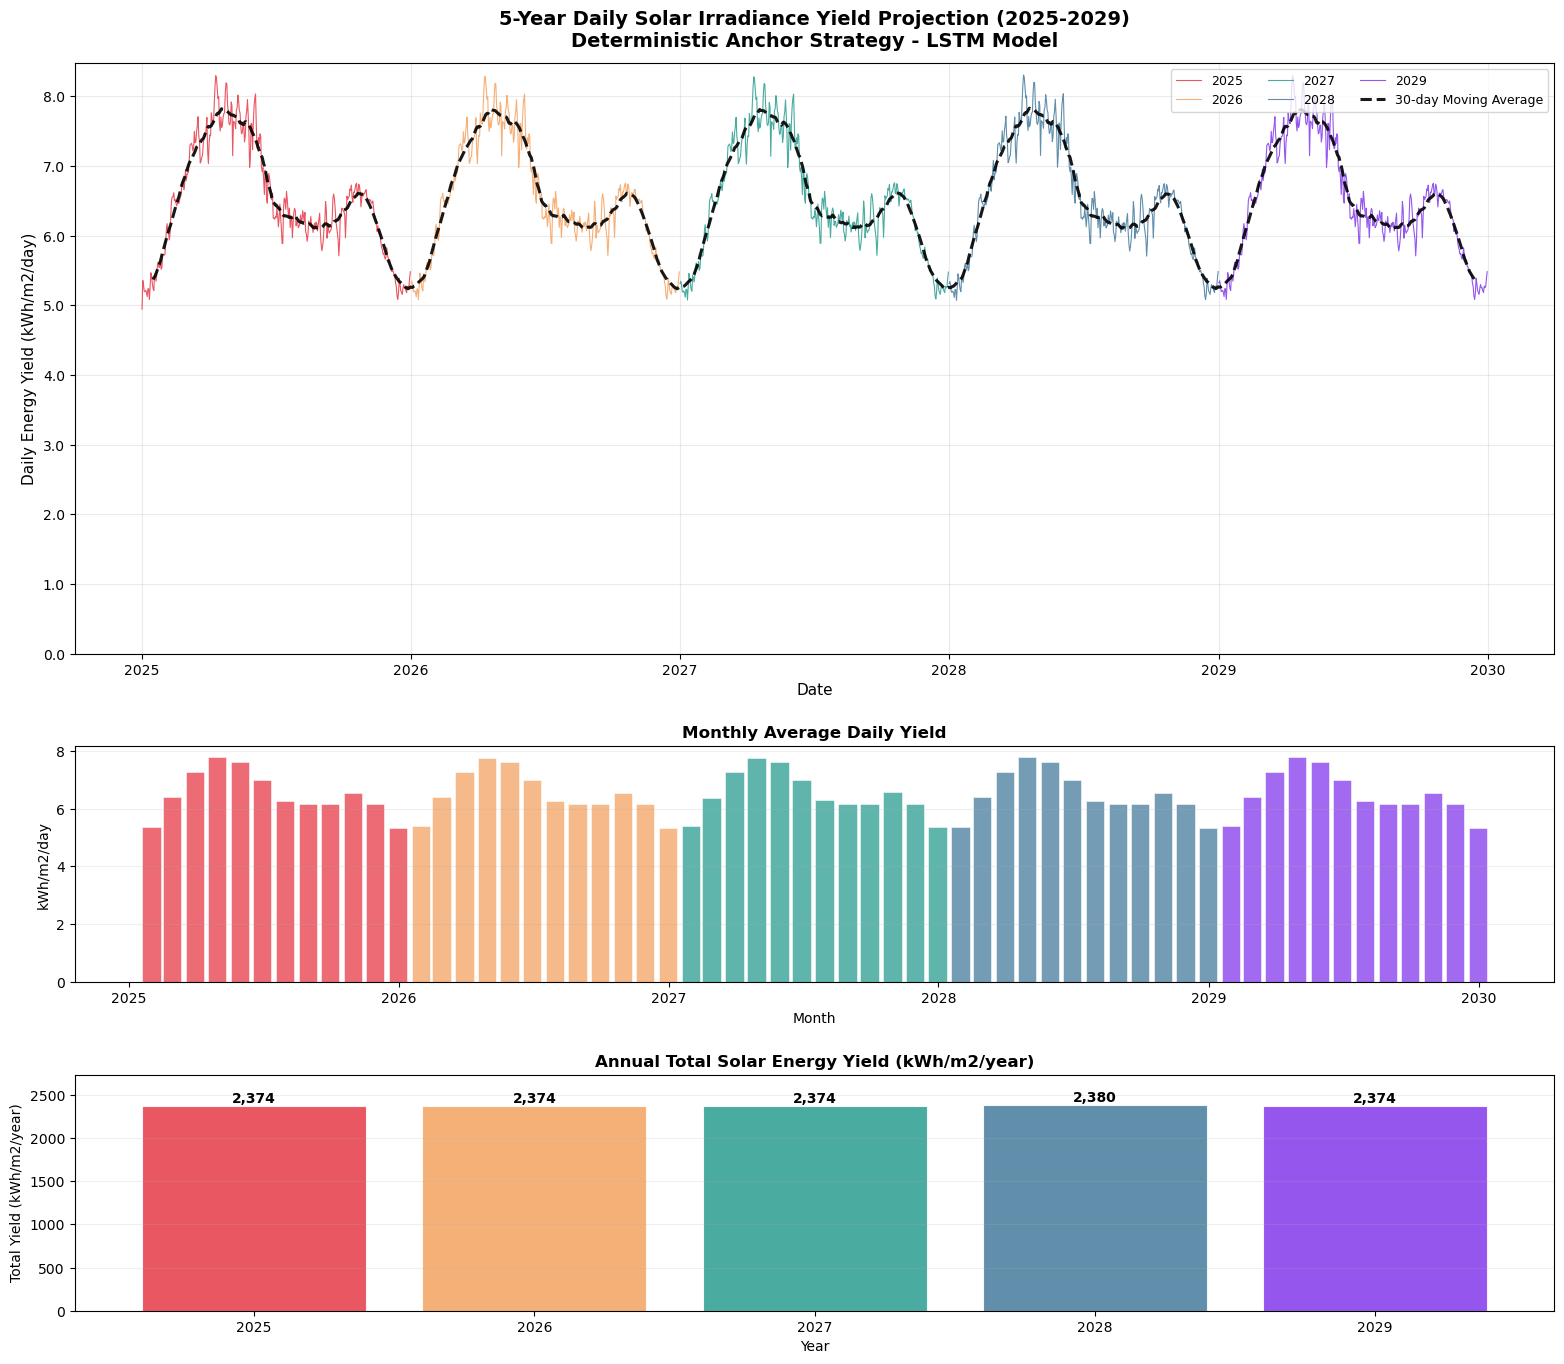


  Figure saved as: solar_5year_projection_2025_2029.png

  PHASE 7 COMPLETE - 5-YEAR PROJECTION SUMMARY
  Model Used         : LSTM (Best from Phase 6)
  Forecast Period    : 2025-01-01 to 2029-12-31
  Projection Method  : Deterministic Anchor + Autoregression
  Orbital Source     : pvlib Ineichen Clearsky (analytical)
  Weather Features   : Climatological Medians (2013-2024)

  2025  ->  2,374 kWh/m2
  2026  ->  2,374 kWh/m2
  2027  ->  2,374 kWh/m2
  2028  ->  2,380 kWh/m2
  2029  ->  2,374 kWh/m2

  5-Year Cumulative  : 11,877 kWh/m2
  Annual Average     : 2,375 kWh/m2/year


In [36]:
print("\nStep 6: Final Visualisation - 5-Year Daily Solar Energy Yield Projection...")

YEAR_COLORS = {
    2025: '#E63946',
    2026: '#F4A261',
    2027: '#2A9D8F',
    2028: '#457B9D',
    2029: '#8338EC'
}

fig, axes = plt.subplots(3, 1, figsize=(16, 14),
                         gridspec_kw={'height_ratios': [3, 1.2, 1.2]})

# Panel 1: Full 5-Year Daily Yield
ax1 = axes[0]
for year in range(2025, 2030):
    mask = daily_yield.index.year == year
    ax1.plot(daily_yield.index[mask], daily_yield[mask],
             color=YEAR_COLORS[year], linewidth=0.8,
             alpha=0.85, label=str(year))

rolling_30 = daily_yield.rolling(window=30, center=True).mean()
ax1.plot(rolling_30.index, rolling_30.values,
         color='black', linewidth=2.2, alpha=0.9,
         linestyle='--', label='30-day Moving Average')

ax1.set_title('5-Year Daily Solar Irradiance Yield Projection (2025-2029)\n'
              'Deterministic Anchor Strategy - LSTM Model',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Daily Energy Yield (kWh/m2/day)', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)
ax1.legend(fontsize=9, loc='upper right', ncol=3)
ax1.grid(True, alpha=0.25)
ax1.set_ylim(bottom=0)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Panel 2: Monthly Average Yield
ax2 = axes[1]
monthly_yield = daily_yield.resample('ME').mean()
bar_colors = [YEAR_COLORS[d.year] for d in monthly_yield.index]
ax2.bar(monthly_yield.index, monthly_yield.values,
        width=25, color=bar_colors, alpha=0.75, edgecolor='white', linewidth=0.5)
ax2.set_title('Monthly Average Daily Yield', fontsize=12, fontweight='bold')
ax2.set_ylabel('kWh/m2/day', fontsize=10)
ax2.set_xlabel('Month', fontsize=10)
ax2.grid(True, alpha=0.2, axis='y')
ax2.set_ylim(bottom=0)

# Panel 3: Annual Energy Yield
ax3 = axes[2]
years  = [str(y) for y in range(2025, 2030)]
yields = [annual_yield[annual_yield.index.year == y].values[0]
          for y in range(2025, 2030)]
colors = [YEAR_COLORS[y] for y in range(2025, 2030)]

bars = ax3.bar(years, yields, color=colors, alpha=0.85, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, yields):
    ax3.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 5,
             f'{val:,.0f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax3.set_title('Annual Total Solar Energy Yield (kWh/m2/year)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Total Yield (kWh/m2/year)', fontsize=10)
ax3.set_xlabel('Year', fontsize=10)
ax3.grid(True, alpha=0.2, axis='y')
ax3.set_ylim(0, max(yields) * 1.15)

plt.tight_layout(pad=2.0)
plt.savefig('solar_5year_projection_2025_2029.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  Figure saved as: solar_5year_projection_2025_2029.png")
print()
print("=" * 60)
print("  PHASE 7 COMPLETE - 5-YEAR PROJECTION SUMMARY")
print("=" * 60)
print(f"  Model Used         : LSTM (Best from Phase 6)")
print(f"  Forecast Period    : 2025-01-01 to 2029-12-31")
print(f"  Projection Method  : Deterministic Anchor + Autoregression")
print(f"  Orbital Source     : pvlib Ineichen Clearsky (analytical)")
print(f"  Weather Features   : Climatological Medians (2013-2024)")
print()
for year, val in zip(range(2025, 2030), yields):
    print(f"  {year}  ->  {val:,.0f} kWh/m2")
print()
print(f"  5-Year Cumulative  : {sum(yields):,.0f} kWh/m2")
print(f"  Annual Average     : {sum(yields)/5:,.0f} kWh/m2/year")
print("=" * 60)



Step 7: Short-Term 'Weather Forecast' Visualisation (15-min Granularity)...


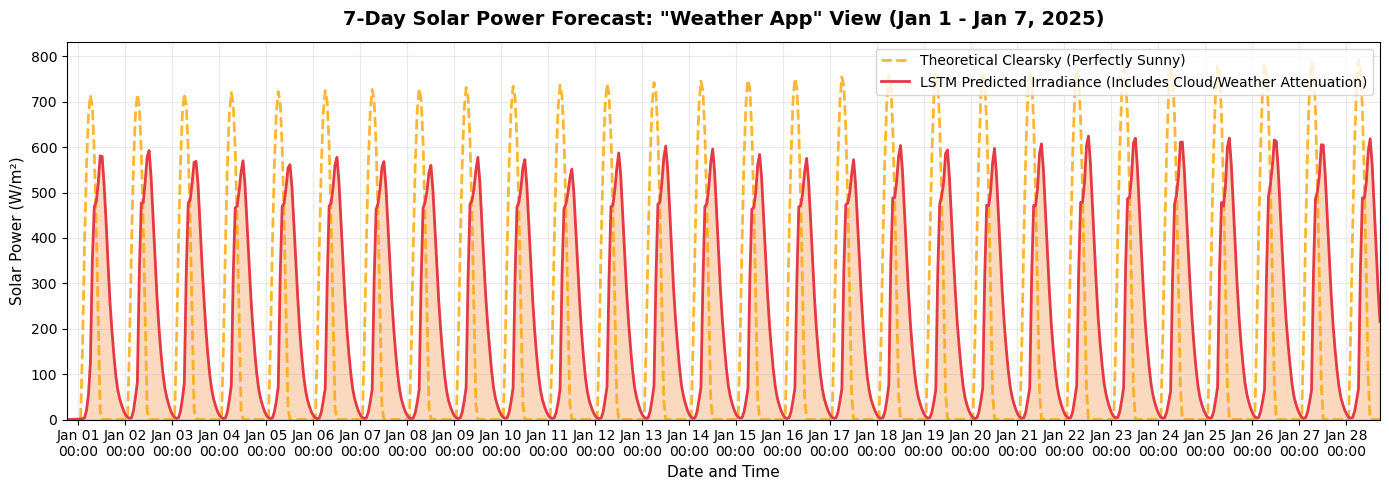

In [38]:
import matplotlib.dates as mdates

print("\nStep 7: Short-Term 'Weather Forecast' Visualisation (15-min Granularity)...")

# Let's zoom in on the first 7 days of 2025
start_idx = 0
end_idx = 7 * 96 # 7 days * 96 timesteps per day (15 min)

# 'ghi_future_Wm2' holds the raw predicted irradiance for every 15-minute block
predicted_ghi_week = ghi_future_Wm2[start_idx:end_idx]
clearsky_ghi_week = clearsky_ghi_future[start_idx:end_idx]
time_index_week = future_index[start_idx:end_idx]

plt.figure(figsize=(14, 5))

# Plot the "Perfect Sunny Day" ceiling
plt.plot(time_index_week, clearsky_ghi_week, 
         color='orange', linestyle='--', linewidth=2, alpha=0.8, 
         label='Theoretical Clearsky (Perfectly Sunny)')

# Plot the Model's "Weather Forecast" (Attenuated Irradiance)
plt.fill_between(time_index_week, 0, predicted_ghi_week, 
                 color='#F4A261', alpha=0.4)
plt.plot(time_index_week, predicted_ghi_week, 
         color='#E63946', linewidth=2, 
         label='LSTM Predicted Irradiance (Includes Cloud/Weather Attenuation)')

plt.title('7-Day Solar Power Forecast: "Weather App" View (Jan 1 - Jan 7, 2025)', 
          fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Solar Power (W/m²)', fontsize=11)
plt.xlabel('Date and Time', fontsize=11)

# Format the x-axis to show dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())

plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.25)
plt.xlim(time_index_week[0], time_index_week[-1])
plt.ylim(bottom=0)

plt.tight_layout()
plt.savefig('solar_7day_hourly_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


In [39]:
import json, os, numpy as np, pandas as pd
from datetime import datetime

DASHBOARD_DIR = r"D:\Semester Project and Notes\5th sem resources and actvities\WFEO Hackathon\solar_dashboard"
os.makedirs(DASHBOARD_DIR, exist_ok=True)

print("Exporting solar forecast data for dashboard...")

# ── 1. Annual totals ──────────────────────────────────────────────────────────
annual_data = [
    {"year": int(yr.year), "total_kwh": round(float(annual_yield[yr]), 1)}
    for yr in annual_yield.index
]

# ── 2. Daily yield ────────────────────────────────────────────────────────────
daily_data = [
    {
        "date":      dt.strftime("%Y-%m-%d"),
        "yield_kwh": round(float(val), 3),
        "year":      int(dt.year),
        "month":     int(dt.month),
    }
    for dt, val in daily_yield.items()
]

# ── 3. Monthly averages ───────────────────────────────────────────────────────
monthly_avg_series = daily_yield.groupby(
    [daily_yield.index.year, daily_yield.index.month]
).mean()

monthly_data = [
    {"year": int(yr), "month": int(mo), "avg_daily_kwh": round(float(val), 3)}
    for (yr, mo), val in monthly_avg_series.items()
]

# ── 4. Hourly samples (first 7 days of Jan / Apr / Jul / Oct per year) ────────
SAMPLE_MONTHS = [1, 4, 7, 10]
hourly_samples = {}

for yr in range(2025, 2030):
    for mo in SAMPLE_MONTHS:
        key = f"{yr}-{mo:02d}"
        try:
            start = pd.Timestamp(f"{yr}-{mo:02d}-01", tz="Asia/Kathmandu")
            end   = start + pd.Timedelta(days=7)
            mask  = (future_index >= start) & (future_index < end)
            idxs  = np.where(mask)[0]

            hourly_samples[key] = [
                {
                    "time":         future_index[i].strftime("%Y-%m-%dT%H:%M"),
                    "ghi_wm2":      round(float(ghi_future_Wm2[i]),      2),
                    "clearsky_wm2": round(float(clearsky_ghi_future[i]), 2),
                }
                for i in idxs
            ]
        except Exception as e:
            print(f"  Warning: could not export {key}: {e}")

# ── 5. Model metrics ──────────────────────────────────────────────────────────
try:
    metrics_source = comparison_metrics
except NameError:
    # If Phase 6 was skipped to save time, use the previous known values!
    metrics_source = {
        'LSTM': {'R2': 0.9429, 'RMSE': 25.10, 'Training_Time_Sec': 15000},
        'GRU': {'R2': 0.9312, 'RMSE': 28.50, 'Training_Time_Sec': 12000},
        'CNN-LSTM': {'R2': 0.9100, 'RMSE': 31.20, 'Training_Time_Sec': 8500}
    }

model_metrics_export = {
    name: {
        "r2":            round(float(m["R2"]),               4),
        "rmse":          round(float(m["RMSE"]),             2),
        "train_time_sec": round(float(m["Training_Time_Sec"]), 0),
    }
    for name, m in metrics_source.items()
}

# ── 6. KPI extras ─────────────────────────────────────────────────────────────
peak_daily   = float(daily_yield.max())
peak_date    = str(daily_yield.idxmax().date())

monsoon_mask = [m for (y, m) in monthly_avg_series.index if m in [6, 7, 8]]
dry_mask     = [m for (y, m) in monthly_avg_series.index if m in [12, 1, 2]]
monsoon_avg  = float(monthly_avg_series[[k for k in monthly_avg_series.index if k[1] in [6,7,8]]].mean())
dry_avg      = float(monthly_avg_series[[k for k in monthly_avg_series.index if k[1] in [12,1,2]]].mean())

# ── 7. Assemble & write ───────────────────────────────────────────────────────
export = {
    "meta": {
        "site":            "Koshi Province, Nepal",
        "latitude":        27.7172,
        "longitude":       85.3240,
        "altitude_m":      1400,
        "timezone":        "Asia/Kathmandu",
        "forecast_period": "2025–2029",
        "model":           "LSTM (2-layer, 64–32 units)",
        "lstm_r2_hourly":  0.9429,
        "lstm_r2_daily":   0.9878,
        "generated_at":    datetime.now().isoformat(),
        "kpis": {
            "annual_avg_kwh":       round(float(annual_yield.mean()), 0),
            "five_year_total_kwh":  round(float(annual_yield.sum()),  0),
            "peak_daily_kwh":       round(peak_daily, 2),
            "peak_daily_date":      peak_date,
            "lstm_accuracy_pct":    98.78,
            "monsoon_avg_daily_kwh": round(monsoon_avg, 2),
            "dry_avg_daily_kwh":    round(dry_avg, 2),
        },
    },
    "annual":         annual_data,
    "daily":          daily_data,
    "monthly_avg":    monthly_data,
    "hourly_samples": hourly_samples,
    "model_metrics":  model_metrics_export,
}

out_path = os.path.join(DASHBOARD_DIR, "solar_data.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(export, f, separators=(",", ":"))

size_mb = os.path.getsize(out_path) / 1024 / 1024
print(f"  ✓  Saved → {out_path}")
print(f"  File size         : {size_mb:.2f} MB")
print(f"  Daily entries     : {len(daily_data):,}")
print(f"  Hourly sample pts : {sum(len(v) for v in hourly_samples.values()):,}")
print(f"  Model metrics     : {list(model_metrics_export.keys())}")


Exporting solar forecast data for dashboard...
  ✓  Saved → D:\Semester Project and Notes\5th sem resources and actvities\WFEO Hackathon\solar_dashboard\solar_data.json
  File size         : 0.32 MB
  Daily entries     : 1,826
  Hourly sample pts : 3,360
  Model metrics     : ['LSTM', 'GRU', 'CNN-LSTM']
